Para evitar el sobreajuste identificado en versiones previas, se incorporaron diversas estrategias de regularización:

Penalización L2 en todos los pesos (kernel_regularizer=l2(1e-3)).

Dropout y SpatialDropout2D (0.2–0.3) para reducir coadaptación entre neuronas y filtros.

Recurrent Dropout (0.2) en las capas ConvLSTM2D para regularizar los estados temporales.

Tasa de aprendizaje inicial baja (1e-4) con control del gradiente mediante clipnorm=1.0.

Pérdida Huber, más robusta frente a valores atípicos.

Esquema de aprendizaje adaptativo mediante cosine decay, ReduceLROnPlateau y EarlyStopping con restauración de los mejores pesos.

Estas modificaciones buscan equilibrar la capacidad de generalización y la estabilidad del entrenamiento, reduciendo la brecha entre las métricas de entrenamiento y validación observadas en los experimentos previos. En conjunto, el modelo ofrece una arquitectura más robusta y generalizable para tareas de predicción espacio-temporal basadas en secuencias de imágenes.

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, Conv2D, TimeDistributed,
    Add, Activation, BatchNormalization, Dropout, SpatialDropout2D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

def resize_npy_images(d_original, d_reducida, new_size=(480, 480)):
    print(f"Redimensionando imágenes en {d_original}...")

    if not os.path.exists(d_reducida):
        os.makedirs(d_reducida)

    processed_count = 0
    for filename in os.listdir(d_original):
        if filename.lower().endswith('.npy'):
            img_path = os.path.join(d_original, filename)
            img_array = np.load(img_path)
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            output_path = os.path.join(d_reducida, filename)
            np.save(output_path, img_resized)
            processed_count += 1

    print(f"Procesadas {processed_count} imágenes")
    return processed_count

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)

    for i in range(n):
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

2025-11-04 13:03:17.801575: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-04 13:03:17.818164: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-04 13:03:17.838160: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-04 13:03:17.843847: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-04 13:03:17.860358: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
# =====================================================
# CONFIGURACIÓN DE RUTAS BANDA 13
# =====================================================
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.layers import Input, ConvLSTM2D, Conv2D, TimeDistributed, BatchNormalization, Activation, Dropout, Add, SpatialDropout2D
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError

d13_reducida = '/home/jhon/bandas/banda13/ene_oct_10m_reducida'
d9_reducida  = '/home/jhon/bandas/banda9/ene_oct_10m_reducida'

# =====================================================
# FUNCIÓN PARA CREAR DATASET EFICIENTE
# =====================================================
def generar_dataset_npy(ruta_banda13, ruta_banda9, timesteps=3, batch_size=1):
    """Crea un dataset eficiente que genera secuencias (X, y) desde archivos .npy de ambas bandas."""

    archivos_13 = sorted([os.path.join(ruta_banda13, f) for f in os.listdir(ruta_banda13) if f.endswith('.npy')])
    archivos_9  = sorted([os.path.join(ruta_banda9,  f) for f in os.listdir(ruta_banda9)  if f.endswith('.npy')])

    # Asegurar que ambas bandas tengan el mismo número de frames
    n_frames = min(len(archivos_13), len(archivos_9))
    archivos_13, archivos_9 = archivos_13[:n_frames], archivos_9[:n_frames]

    # Cargar ejemplo para inferir tamaño
    ejemplo = np.load(archivos_13[0])
    H, W = ejemplo.shape[:2]
    C = 2  # 2 bandas

    def cargar_secuencia(idx):
        idx = int(idx.numpy())
        start, end = idx, idx + timesteps

        # Cargar timesteps para ambas bandas
        seq_13 = [np.load(archivos_13[i]).astype(np.float32) for i in range(start, end)]
        seq_9  = [np.load(archivos_9[i]).astype(np.float32) for i in range(start, end)]
        seq_13 = np.stack(seq_13, axis=0)[..., np.newaxis]
        seq_9  = np.stack(seq_9, axis=0)[..., np.newaxis]

        # Combinar las bandas → (t, H, W, 2)
        X = np.concatenate([seq_13, seq_9], axis=-1)

        # Frame siguiente como salida (solo siguiente timestep)
        y13 = np.load(archivos_13[end]).astype(np.float32)[..., np.newaxis]
        y9  = np.load(archivos_9[end]).astype(np.float32)[..., np.newaxis]
        y = np.concatenate([y13, y9], axis=-1)

        return X, y

    def map_func(i):
        X, y = tf.py_function(cargar_secuencia, [i], [tf.float32, tf.float32])
        X.set_shape((timesteps, H, W, C))
        y.set_shape((H, W, C))
        return X, y

    # Crear índices válidos
    n_seq = n_frames - timesteps - 1
    idxs = tf.data.Dataset.range(n_seq)

    # Crear dataset eficiente
    ds = idxs.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds, n_seq, H, W, C


# =====================================================
# CREAR DATASETS
# =====================================================
print("=" * 50)
print("CREANDO DATASETS EFICIENTES")
print("=" * 50)

timesteps = 3
batch_size = 1
porc_validacion = 0.2

# Crear dataset total
dataset, total_secuencias, H, W, C = generar_dataset_npy(
    d13_reducida, d9_reducida,
    timesteps=timesteps,
    batch_size=batch_size
)

# Calcular tamaño de entrenamiento y validación
n_val = int(total_secuencias * porc_validacion)
n_train = total_secuencias - n_val

# Dividir dataset
train_ds = dataset.take(n_train)
val_ds = dataset.skip(n_train)

print(f"✅ Dataset creado correctamente:")
print(f"   - Total secuencias: {total_secuencias}")
print(f"   - Entrenamiento: {n_train}")
print(f"   - Validación: {n_val}")
print(f"   - Tamaño imágenes: H={H}, W={W}, C={C}")


# =====================================================
# PARÁMETROS GENERALES
# =====================================================
semilla = 42
tf.random.set_seed(semilla)

# =====================================================
# FUNCIÓN DE DECAY COSENO
# =====================================================
initial_lr = 1e-4
min_lr = 1e-6
epochs_total = 50
warmup_epochs = 5

def cosine_decay_schedule(epoch, lr):
    if epoch < warmup_epochs:
        return initial_lr
    progress = (epoch - warmup_epochs) / (epochs_total - warmup_epochs)
    progress = np.clip(progress, 0, 1)
    cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
    lr_new = min_lr + (initial_lr - min_lr) * cosine_decay
    return lr_new


# =====================================================
# CONSTRUCCIÓN DEL MODELO (ConvLSTM2D)
# =====================================================
inputs = Input(shape=(timesteps, H, W, C), name='input_sequence')

block1_conv3x3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True,
                            kernel_regularizer=l2(1e-3), recurrent_dropout=0.2, name='block1_conv3x3')(inputs)
block1_conv3x3 = TimeDistributed(BatchNormalization())(block1_conv3x3)
block1_conv3x3 = Activation('relu')(block1_conv3x3)
block1_conv3x3 = TimeDistributed(SpatialDropout2D(0.2))(block1_conv3x3)

block1_conv5x5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True,
                            kernel_regularizer=l2(1e-3), recurrent_dropout=0.2, name='block1_conv5x5')(inputs)
block1_conv5x5 = TimeDistributed(BatchNormalization())(block1_conv5x5)
block1_conv5x5 = Activation('relu')(block1_conv5x5)
block1_conv5x5 = TimeDistributed(SpatialDropout2D(0.2))(block1_conv5x5)

block1 = Add()([block1_conv3x3, block1_conv5x5])
block1 = Activation('relu', name='block1_output')(block1)
block1 = Dropout(0.3)(block1)

residual = block1

block2_conv3x3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True,
                            kernel_regularizer=l2(1e-3), recurrent_dropout=0.2, name='block2_conv3x3')(block1)
block2_conv3x3 = TimeDistributed(BatchNormalization())(block2_conv3x3)
block2_conv3x3 = Activation('relu')(block2_conv3x3)
block2_conv3x3 = TimeDistributed(SpatialDropout2D(0.2))(block2_conv3x3)

block2_conv5x5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True,
                            kernel_regularizer=l2(1e-3), recurrent_dropout=0.2, name='block2_conv5x5')(block1)
block2_conv5x5 = TimeDistributed(BatchNormalization())(block2_conv5x5)
block2_conv5x5 = Activation('relu')(block2_conv5x5)
block2_conv5x5 = TimeDistributed(SpatialDropout2D(0.2))(block2_conv5x5)

block2 = Add()([block2_conv3x3, block2_conv5x5, residual])
block2 = Activation('relu', name='block2_output')(block2)
block2 = Dropout(0.3)(block2)

block3_conv3x3 = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=True,
                            kernel_regularizer=l2(1e-3), recurrent_dropout=0.2, name='block3_conv3x3')(block2)
block3_conv3x3 = TimeDistributed(BatchNormalization())(block3_conv3x3)
block3_conv3x3 = Activation('relu')(block3_conv3x3)

block3_conv5x5 = ConvLSTM2D(16, (5, 5), padding='same', return_sequences=True,
                            kernel_regularizer=l2(1e-3), recurrent_dropout=0.2, name='block3_conv5x5')(block2)
block3_conv5x5 = TimeDistributed(BatchNormalization())(block3_conv5x5)
block3_conv5x5 = Activation('relu')(block3_conv5x5)

block3 = Add()([block3_conv3x3, block3_conv5x5])
block3 = Activation('relu', name='block3_output')(block3)
block3 = Dropout(0.3)(block3)

final_convLSTM = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=False,
                            kernel_regularizer=l2(1e-3), recurrent_dropout=0.2, name='final_convLSTM')(block3)

outputs = Conv2D(2, (1, 1), padding='same', activation='linear', name='output')(final_convLSTM)

model17_2b = Model(inputs=inputs, outputs=outputs, name='ConvLSTM17_2_Bandas')

# =====================================================
# COMPILACIÓN Y CALLBACKS
# =====================================================
optimizer = Adam(learning_rate=initial_lr)
model17_2b.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(),
                   metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath="modelo17_2b_best.h5", monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    LearningRateScheduler(cosine_decay_schedule, verbose=1)
]

print("✅ Modelo 17 con dos bandas")
model17_2b.summary()

# =====================================================
# ENTRENAMIENTO
# =====================================================
print("\n" + "=" * 50)
print("INICIANDO ENTRENAMIENTO")
print("=" * 50)

history17_2b = model17_2b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_total,
    callbacks=callbacks,
    verbose=1
)

print("✅ ¡Entrenamiento completado!")


CREANDO DATASETS EFICIENTES
✅ Dataset creado correctamente:
   - Total secuencias: 7246
   - Entrenamiento: 5797
   - Validación: 1449
   - Tamaño imágenes: H=480, W=480, C=2
✅ Modelo 17 con dos bandas


Model: "ConvLSTM17_2_Bandas"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 3, 480,    │          0 │ -                 │
│ (InputLayer)        │ 480, 2)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv3x3      │ (None, 3, 480,    │     10,432 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv5x5      │ (None, 3, 480,    │     28,864 │ input_sequence[0… │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_20 │ (None, 3, 480,    │         64 │ block1_conv3x3[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_22 │ (None, 3, 480,    │         64 │ block1_conv5x5[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 3, 480,    │          0 │ time_distributed… │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_21 │ (None, 3, 480,    │          0 │ activation_12[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_23 │ (None, 3, 480,    │          0 │ activation_13[0]… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 3, 480,    │          0 │ time_distributed… │
│                     │ 480, 16)          │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_output       │ (None, 3, 480,    │          0 │ add_6[0][0]       │
│ (Activation)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 3, 480,    │          0 │ block1_output[0]… │
│                     │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv3x3      │ (None, 3, 480,    │     18,496 │ dropout_6[0][0]   │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv5x5      │ (None, 3, 480,    │     51,264 │ dropout_6[0][0]   │
│ (ConvLSTM2D)        │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_24 │ (None, 3, 480,    │         64 │ block2_conv3x3[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_26 │ (None, 3, 480,    │         64 │ block2_conv5x5[0… │
│ (TimeDistributed)   │ 480, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 3, 480,    │          0 │ time_distributed

 Total params: 197,730 (772.38 KB)

 Trainable params: 197,538 (771.63 KB)

...

5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1009s 174ms/step - loss: 13.0754 - mean_absolute_percentage_error: 24.0148 - root_mean_squared_error: 21.7002 - val_loss: 11.7677 - val_mean_absolute_percentage_error: 24.3056 - val_root_mean_squared_error: 19.4261 - learning_rate: 1.0000e-04

Epoch 7: LearningRateScheduler setting learning rate to 9.98794204878613e-05.
Epoch 7/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 12.1623 - mean_absolute_percentage_error: 22.9555 - root_mean_squared_error: 19.5328
Epoch 7: val_loss did not improve from 11.76775
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1009s 174ms/step - loss: 10.1596 - mean_absolute_percentage_error: 21.3385 - root_mean_squared_error: 17.0794 - val_loss: 16.6953 - val_mean_absolute_percentage_error: 43.2914 - val_root_mean_squared_error: 25.1751 - learning_rate: 9.9879e-05

Epoch 8: LearningRateScheduler setting learning rate to 9.951826940270773e-05.
Epoch 8/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 9.3154 - mean_absolute_percentag

5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1007s 174ms/step - loss: 6.0646 - mean_absolute_percentage_error: 17.1955 - root_mean_squared_error: 10.5306 - val_loss: 10.7344 - val_mean_absolute_percentage_error: 30.6363 - val_root_mean_squared_error: 16.8860 - learning_rate: 9.8918e-05

Epoch 10: LearningRateScheduler setting learning rate to 9.808245394894679e-05.
Epoch 10/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 5.2978 - mean_absolute_percentage_error: 15.8169 - root_mean_squared_error: 9.1783
Epoch 10: val_loss did not improve from 10.73442
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1008s 174ms/step - loss: 4.8446 - mean_absolute_percentage_error: 15.7328 - root_mean_squared_error: 8.9242 - val_loss: 12.6425 - val_mean_absolute_percentage_error: 33.7267 - val_root_mean_squared_error: 19.7776 - learning_rate: 9.8082e-05

Epoch 11: LearningRateScheduler setting learning rate to 9.701478472890247e-05.
Epoch 11/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 4.2415 - mean_absolute_percenta

5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1007s 174ms/step - loss: 3.8220 - mean_absolute_percentage_error: 13.7902 - root_mean_squared_error: 8.0155 - val_loss: 8.8210 - val_mean_absolute_percentage_error: 25.8893 - val_root_mean_squared_error: 14.0198 - learning_rate: 9.2478e-05

Epoch 15: LearningRateScheduler setting learning rate to 9.05463412215599e-05.
Epoch 15/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 3.5442 - mean_absolute_percentage_error: 12.3356 - root_mean_squared_error: 7.4866
Epoch 15: val_loss did not improve from 8.82103
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1005s 173ms/step - loss: 3.7860 - mean_absolute_percentage_error: 13.6215 - root_mean_squared_error: 7.9809 - val_loss: 9.8037 - val_mean_absolute_percentage_error: 27.7679 - val_root_mean_squared_error: 15.4807 - learning_rate: 9.0546e-05

Epoch 16: LearningRateScheduler setting learning rate to 8.84191999343894e-05.
Epoch 16/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 3.5119 - mean_absolute_percentage_err

5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1006s 174ms/step - loss: 3.7615 - mean_absolute_percentage_error: 13.5319 - root_mean_squared_error: 7.9618 - val_loss: 8.4614 - val_mean_absolute_percentage_error: 25.5558 - val_root_mean_squared_error: 13.4486 - learning_rate: 8.8419e-05

Epoch 17: LearningRateScheduler setting learning rate to 8.610732011676324e-05.
Epoch 17/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 3.4716 - mean_absolute_percentage_error: 12.0606 - root_mean_squared_error: 7.4286
Epoch 17: val_loss did not improve from 8.46142
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1005s 173ms/step - loss: 3.7338 - mean_absolute_percentage_error: 13.4383 - root_mean_squared_error: 7.9366 - val_loss: 8.6923 - val_mean_absolute_percentage_error: 25.7002 - val_root_mean_squared_error: 13.8188 - learning_rate: 8.6107e-05

Epoch 18: LearningRateScheduler setting learning rate to 8.362196501476348e-05.
Epoch 18/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 3.4490 - mean_absolute_percentage_e

5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1007s 174ms/step - loss: 3.7209 - mean_absolute_percentage_error: 13.3972 - root_mean_squared_error: 7.9334 - val_loss: 6.8695 - val_mean_absolute_percentage_error: 21.8371 - val_root_mean_squared_error: 11.4430 - learning_rate: 8.3622e-05

Epoch 19: LearningRateScheduler setting learning rate to 8.097524302862009e-05.
Epoch 19/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 3.4194 - mean_absolute_percentage_error: 11.8907 - root_mean_squared_error: 7.3883
Epoch 19: val_loss did not improve from 6.86952
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 1004s 173ms/step - loss: 3.6987 - mean_absolute_percentage_error: 13.3202 - root_mean_squared_error: 7.9094 - val_loss: 7.1581 - val_mean_absolute_percentage_error: 22.6405 - val_root_mean_squared_error: 11.7927 - learning_rate: 8.0975e-05

Epoch 20: LearningRateScheduler setting learning rate to 7.818004872180197e-05.
Epoch 20/50
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 3.4000 - mean_absolute_percentage_e

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 3.6109, RMSE final: 7.8197, MAPE final: 13.0273
Validación    - Loss final: 11.1174, RMSE final: 17.3347, MAPE final: 30.4516


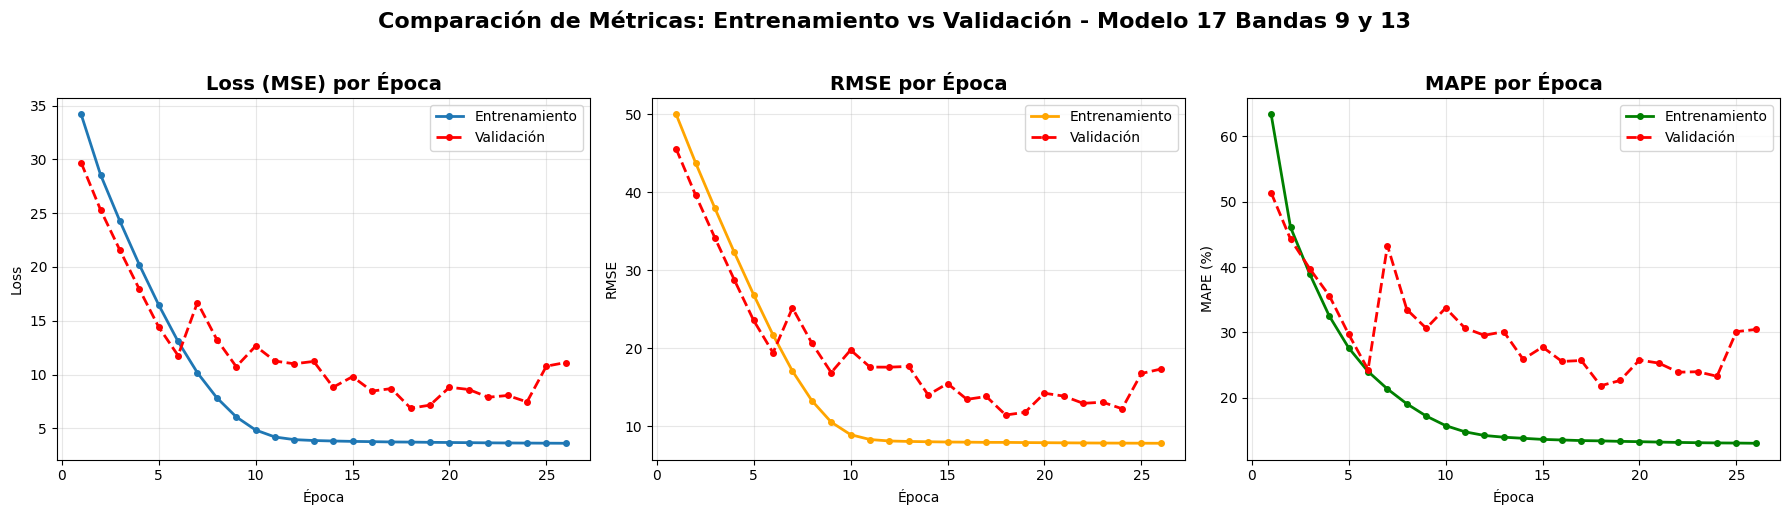

In [8]:

# Extraer métricas del historial (entrenamiento y validación)
loss = history17_2b.history['loss']
val_loss = history17_2b.history['val_loss']

rmse = history17_2b.history['root_mean_squared_error']
val_rmse = history17_2b.history['val_root_mean_squared_error']

mape = history17_2b.history['mean_absolute_percentage_error']
val_mape = history17_2b.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 17 Bandas 9 y 13',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [30]:
# =====================================================
# EVALUACIÓN EN VALIDACIÓN
# =====================================================
loss_val, rmse_val, mape_val = model17_2b.evaluate(val_ds, verbose=1)

print(f"🔹 Validación → Pérdida (MSE): {loss_val:.6f}")
print(f"🔹 Validación → RMSE: {rmse_val:.6f}")
print(f"🔹 Validación → MAPE: {mape_val:.6f}")


1449/1449 ━━━━━━━━━━━━━━━━━━━━ 92s 42ms/step - loss: 6.8695 - mean_absolute_percentage_error: 21.8371 - root_mean_squared_error: 11.4430
🔹 Validación → Pérdida (MSE): 6.869522
🔹 Validación → RMSE: 11.442973
🔹 Validación → MAPE: 21.837149


In [31]:
# =====================================================
# EVALUACIÓN DE MÉTRICAS
# =====================================================

print("=" * 50)
print("🔹 EVALUANDO MODELO EN ENTRENAMIENTO")
print("=" * 50)

loss_train, rmse_train, mape_train = model17_2b.evaluate(train_ds, verbose=1)
print(f"Entrenamiento → Pérdida (MSE): {loss_train:.6f}")
print(f"Entrenamiento → RMSE: {rmse_train:.6f}")
print(f"Entrenamiento → MAPE: {mape_train:.6f}")

🔹 EVALUANDO MODELO EN ENTRENAMIENTO
5797/5797 ━━━━━━━━━━━━━━━━━━━━ 246s 42ms/step - loss: 6.1326 - mean_absolute_percentage_error: 20.7481 - root_mean_squared_error: 10.0010
Entrenamiento → Pérdida (MSE): 6.132571
Entrenamiento → RMSE: 10.001040
Entrenamiento → MAPE: 20.748083


Visualizacion

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def mostrar_comparacion_bandas(X, y, y_pred, n=5, cmap='viridis',
                               titulo_general="Comparación de Bandas (13 y 9)",
                               xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre la entrada (último frame), la salida real y la salida predicha
    para ambas bandas (13 y 9), con un esquema de color unificado.
    """
    n = min(n, len(X))

    for i in range(n):
        entrada = X[i, -1]   # último frame de la secuencia
        real = y[i]
        pred = y_pred[i]

        fig, axs = plt.subplots(2, 3, figsize=(12, 6))
        fig.suptitle(f"{titulo_general} - Muestra {i+1}", fontsize=16, y=1.02)

        # ==================== Banda 13 ====================
        axs[0, 0].imshow(entrada[..., 0], cmap=cmap)
        axs[0, 0].set_title("Entrada (Banda 13)")
        axs[0, 0].set_xlabel(xlabel)
        axs[0, 0].set_ylabel(ylabel)

        axs[0, 1].imshow(real[..., 0], cmap=cmap)
        axs[0, 1].set_title("Real (Banda 13)")
        axs[0, 1].set_xlabel(xlabel)
        axs[0, 1].set_ylabel(ylabel)

        axs[0, 2].imshow(pred[..., 0], cmap=cmap)
        axs[0, 2].set_title("Predicción (Banda 13)")
        axs[0, 2].set_xlabel(xlabel)
        axs[0, 2].set_ylabel(ylabel)

        # ==================== Banda 9 ====================
        axs[1, 0].imshow(entrada[..., 1], cmap=cmap)
        axs[1, 0].set_title("Entrada (Banda 9)")
        axs[1, 0].set_xlabel(xlabel)
        axs[1, 0].set_ylabel(ylabel)

        axs[1, 1].imshow(real[..., 1], cmap=cmap)
        axs[1, 1].set_title("Real (Banda 9)")
        axs[1, 1].set_xlabel(xlabel)
        axs[1, 1].set_ylabel(ylabel)

        axs[1, 2].imshow(pred[..., 1], cmap=cmap)
        axs[1, 2].set_title("Predicción (Banda 9)")
        axs[1, 2].set_xlabel(xlabel)
        axs[1, 2].set_ylabel(ylabel)

        plt.tight_layout()
        plt.show()


✅ Se extrajeron 2 muestras de validación
🔮 Generando predicciones...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


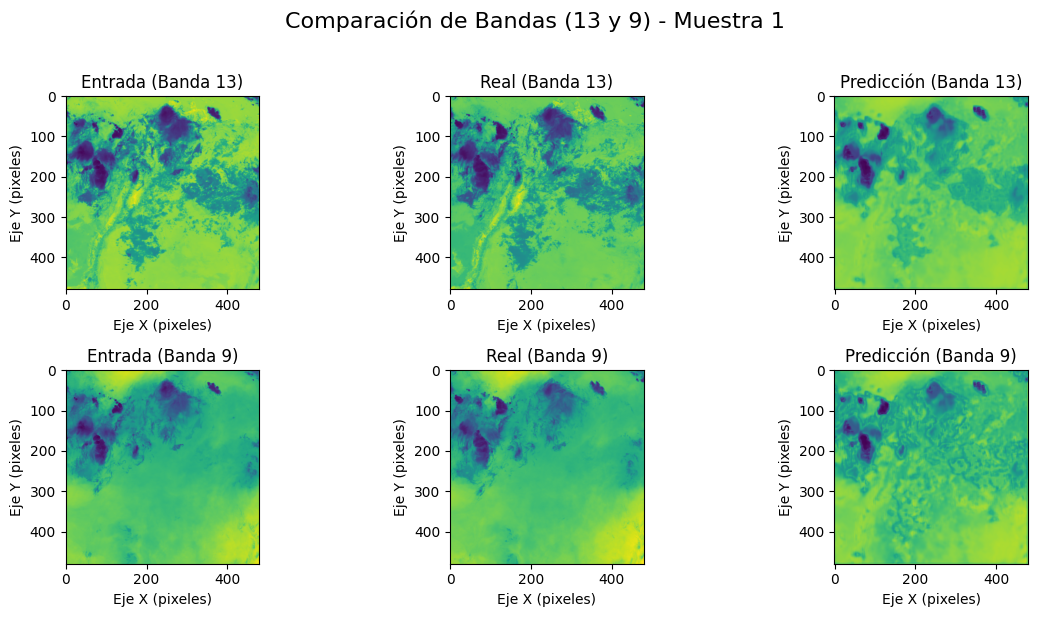

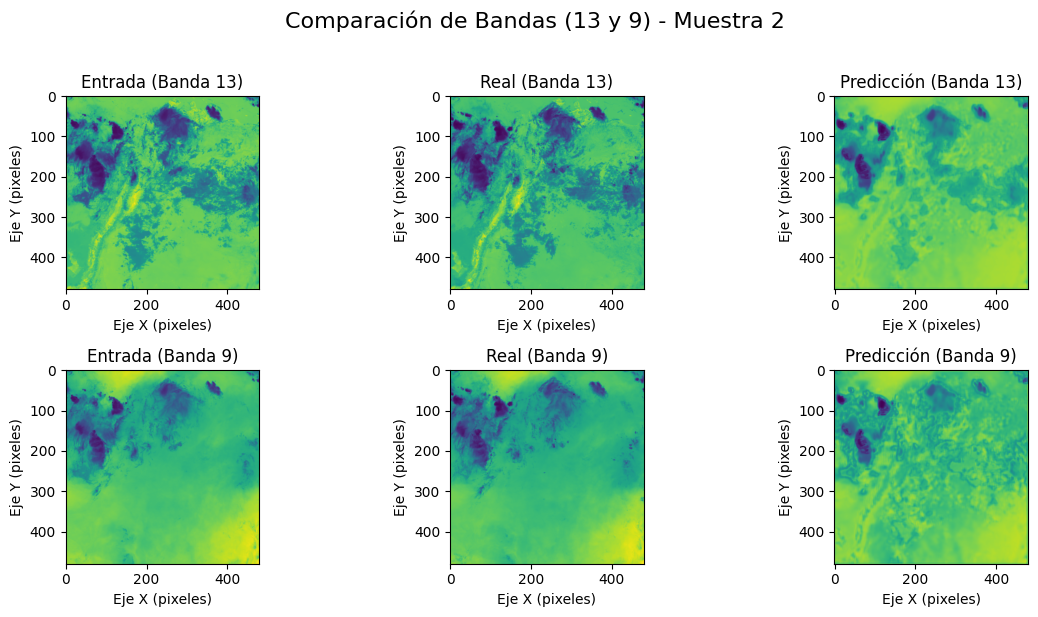

In [27]:
import numpy as np

# ================================
# Extraer primeras 5 secuencias del val_ds
# ================================
num_muestras = 2
X_val_list, y_val_list = [], []

for X_batch, y_batch in val_ds.take(num_muestras):
    X_val_list.append(X_batch.numpy())
    y_val_list.append(y_batch.numpy())

# Convertir a arreglos NumPy
X_val = np.concatenate(X_val_list, axis=0)
y_val = np.concatenate(y_val_list, axis=0)

print(f"✅ Se extrajeron {len(X_val)} muestras de validación")

# ================================
# Generar predicciones
# ================================
print("🔮 Generando predicciones...")
y_pred_2b = model17_2b.predict(X_val)

# ================================
# Visualización
# ================================
mostrar_comparacion_bandas(X_val, y_val, y_pred_2b, n=5)


In [2]:
# Cargar el modelo con los pesos de la mejor época
model = tf.keras.models.load_model('modelo17_2b_best.h5')
print("✅ Modelo cargado con pesos de la mejor época")

# Verificar que es el modelo correcto
print(f"Nombre del modelo: {model.name}")
print(f"Arquitectura cargada correctamente")

2025-11-04 11:20:34.371497: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46779 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:52:00.0, compute capability: 8.6


✅ Modelo cargado con pesos de la mejor época
Nombre del modelo: ConvLSTM17_2_Bandas
Arquitectura cargada correctamente


🔍 DIAGNÓSTICO PROFUNDO DEL PROBLEMA
📊 DISTRIBUCIÓN ORIGINAL DE DATOS:
Min: 0.0006400271
Max: 0.0006
Mean: 0.00064003
Std: 0.00000000

🔎 ANÁLISIS DE VALORES CERCANOS A CERO:
 < 1e-10: 0 (0.00%) | ≥ 1e-10: 1,152,000 (100.00%)
 < 1e-08: 0 (0.00%) | ≥ 1e-08: 1,152,000 (100.00%)
 < 1e-06: 0 (0.00%) | ≥ 1e-06: 1,152,000 (100.00%)
 < 1e-04: 0 (0.00%) | ≥ 1e-04: 1,152,000 (100.00%)
 < 1e-03: 1,152,000 (100.00%) | ≥ 1e-03: 0 (0.00%)
 < 1e-02: 1,152,000 (100.00%) | ≥ 1e-02: 0 (0.00%)

🔄 COMPARANDO DIFERENTES ESTRATEGIAS DE TRANSFORMACIÓN

📊 SIN TRANSFORMACIÓN:
   • SMAPE: 197.2038%
   • MAE: 7.386297
   • Correlación: 0.9477

🎯 EVALUACIÓN CON TRANSFORMACIÓN 'LOG'


/tmp/ipykernel_11128/190167882.py:132: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean((y_true_flat - y_pred_flat) ** 2))
/home/jhon/cloud/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


📈 RESULTADOS CON TRANSFORMACIÓN 'LOG':
   • Loss (Huber):    37344674942900240384.000000
   • MAE:            37339652373784559616.000000
   • RMSE:           inf
   • SMAPE:          200.0000%
   • Correlación:    0.0013

🎯 EVALUACIÓN CON TRANSFORMACIÓN 'SQRT'
📈 RESULTADOS CON TRANSFORMACIÓN 'SQRT':
   • Loss (Huber):    91.415169
   • MAE:            91.914909
   • RMSE:           142.021072
   • SMAPE:          199.9056%
   • Correlación:    0.7974

🎯 EVALUACIÓN CON TRANSFORMACIÓN 'SCALE'
📈 RESULTADOS CON TRANSFORMACIÓN 'SCALE':
   • Loss (Huber):    91.415176
   • MAE:            91.914909
   • RMSE:           142.021072
   • SMAPE:          199.9056%
   • Correlación:    0.7974

🎯 RECOMENDACIÓN FINAL BASADA EN RESULTADOS
✅ MEJOR TRANSFORMACIÓN: 'NONE'
   • SMAPE: 197.2038%

📋 RESUMEN COMPARATIVO:
   NONE     -> SMAPE: 197.2038% | MAE: 7.386297 | Corr: 0.9477
   LOG      -> SMAPE: 200.0000% | MAE: 37339652373784559616.000000 | Corr: 0.0013
   SQRT     -> SMAPE: 199.9056% | MAE: 91.

IndexError: index 2 is out of bounds for axis 0 with size 2

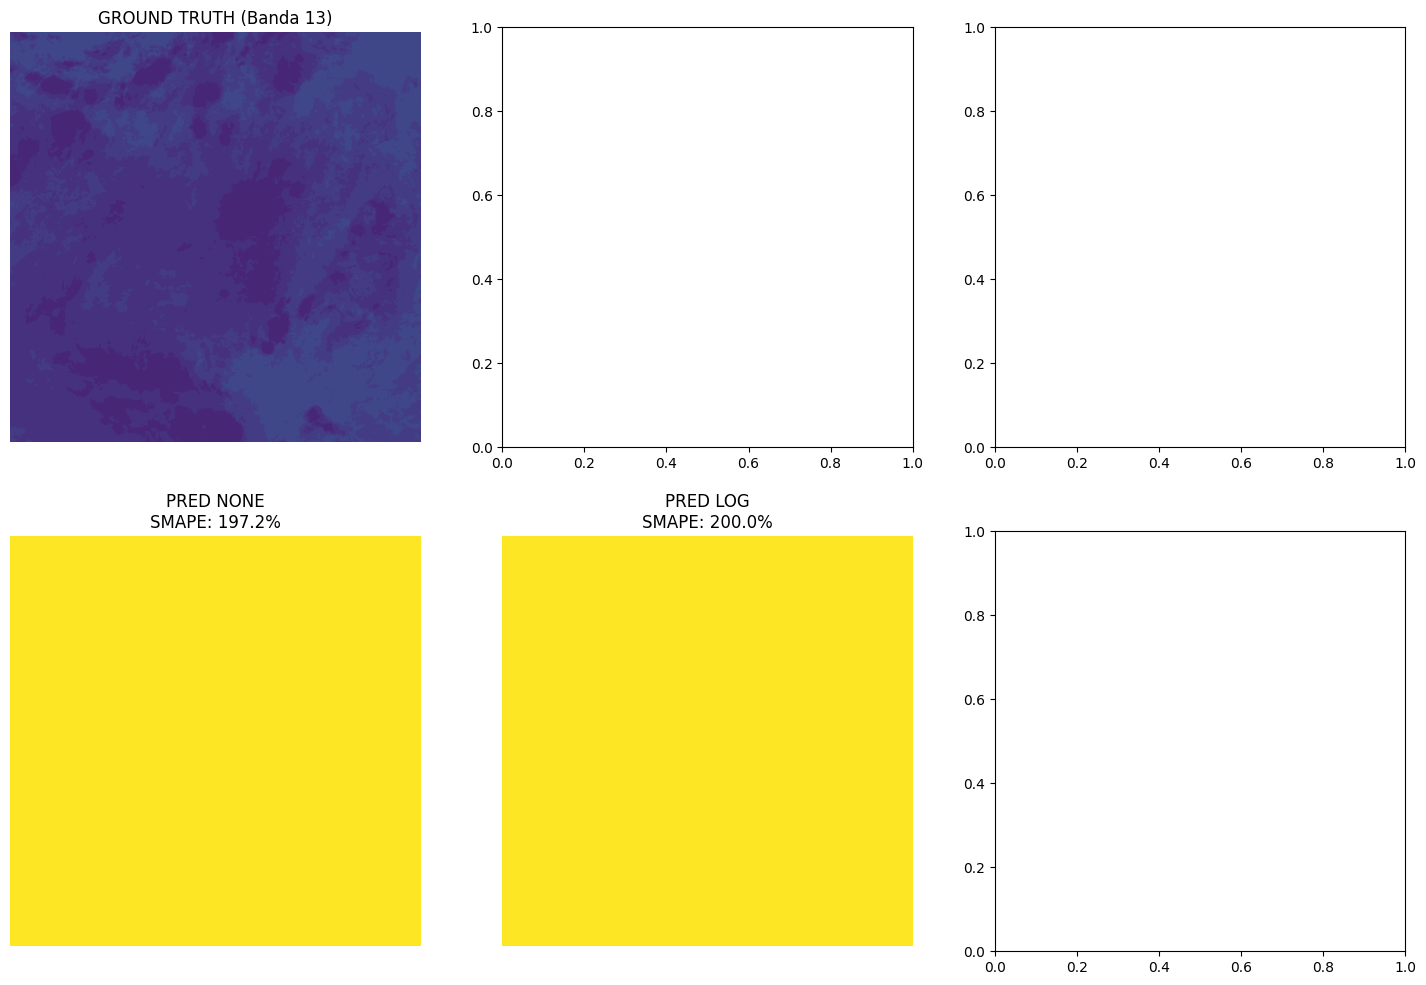

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.metrics import RootMeanSquaredError
import matplotlib.pyplot as plt
import os

# =====================================================
# DIAGNÓSTICO PROFUNDO Y SOLUCIÓN
# =====================================================
print("🔍 DIAGNÓSTICO PROFUNDO DEL PROBLEMA")

# Cargar algunos datos originales para análisis
sample_files_13 = sorted([f for f in os.listdir(prueba_13_red) if f.endswith('.npy')])[:5]
sample_data_13 = [np.load(os.path.join(prueba_13_red, f)) for f in sample_files_13]
all_pixels_13 = np.concatenate([img.flatten() for img in sample_data_13])

print("📊 DISTRIBUCIÓN ORIGINAL DE DATOS:")
print(f"Min: {np.min(all_pixels_13):.10f}")
print(f"Max: {np.max(all_pixels_13):.4f}")
print(f"Mean: {np.mean(all_pixels_13):.8f}")
print(f"Std: {np.std(all_pixels_13):.8f}")

# Análisis detallado de valores pequeños
print("\n🔎 ANÁLISIS DE VALORES CERCANOS A CERO:")
thresholds = [1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2]
for threshold in thresholds:
    below = np.sum(all_pixels_13 < threshold)
    above = np.sum(all_pixels_13 >= threshold)
    total = len(all_pixels_13)
    print(f" < {threshold:.0e}: {below:,} ({below/total*100:.2f}%) | ≥ {threshold:.0e}: {above:,} ({above/total*100:.2f}%)")

# =====================================================
# ESTRATEGIA: TRANSFORMACIÓN DE DATOS
# =====================================================
def apply_data_transformation(images, transformation='log', epsilon=1e-6):
    """
    Aplicar transformación para manejar valores cercanos a cero
    """
    transformed = []
    
    for img in images:
        if transformation == 'log':
            # Transformación logarítmica (suaviza valores pequeños)
            img_transformed = np.log1p(np.abs(img) + epsilon)  # log(1 + x)
        elif transformation == 'sqrt':
            # Raíz cuadrada (reduce el rango)
            img_transformed = np.sqrt(np.abs(img) + epsilon)
        elif transformation == 'scale':
            # Escalado no lineal
            img_transformed = np.sign(img) * np.power(np.abs(img), 0.5)
        else:
            img_transformed = img.copy()
        
        transformed.append(img_transformed)
    
    return np.array(transformed)

def inverse_data_transformation(images, transformation='log', epsilon=1e-6):
    """
    Transformación inversa para recuperar escala original
    """
    inverse = []
    
    for img in images:
        if transformation == 'log':
            img_inverse = np.expm1(img) - epsilon
        elif transformation == 'sqrt':
            img_inverse = np.square(img) - epsilon
        elif transformation == 'scale':
            img_inverse = np.sign(img) * np.power(np.abs(img), 2)
        else:
            img_inverse = img.copy()
        
        inverse.append(img_inverse)
    
    return np.array(inverse)

# =====================================================
# EVALUACIÓN CON TRANSFORMACIÓN
# =====================================================
def evaluate_with_transformation(model, X_seq, y_seq, transformation='log'):
    """
    Evaluar con transformación de datos
    """
    print(f"\n🎯 EVALUACIÓN CON TRANSFORMACIÓN '{transformation.upper()}'")
    print("="*60)
    
    # Aplicar transformación a los datos de salida
    y_seq_transformed = apply_data_transformation(y_seq, transformation)
    
    # Métricas durante la transformación
    huber_loss = tf.keras.losses.Huber()
    rmse_metric = RootMeanSquaredError()
    
    total_loss = 0
    batch_size = 8
    
    # Predicciones por lotes
    y_pred_transformed = []
    for i in range(0, len(X_seq), batch_size):
        end_idx = min(i + batch_size, len(X_seq))
        X_batch = X_seq[i:end_idx]
        y_batch = y_seq_transformed[i:end_idx]
        
        # Predecir en espacio transformado
        y_pred_batch = model.predict(X_batch, verbose=0)
        y_pred_transformed.append(y_pred_batch)
        
        # Métricas en espacio transformado
        batch_loss = huber_loss(y_batch, y_pred_batch).numpy()
        rmse_metric.update_state(y_batch, y_pred_batch)
        total_loss += batch_loss
    
    y_pred_transformed = np.concatenate(y_pred_transformed, axis=0)
    
    # Convertir de vuelta a espacio original
    y_pred_original = inverse_data_transformation(y_pred_transformed, transformation)
    
    # Calcular métricas en espacio original
    loss_original = huber_loss(y_seq, y_pred_original).numpy()
    
    # Métricas robustas
    y_true_flat = y_seq.flatten()
    y_pred_flat = y_pred_original.flatten()
    
    # SMAPE en espacio original
    smape = 100 * np.mean(2 * np.abs(y_pred_flat - y_true_flat) / 
                          (np.abs(y_true_flat) + np.abs(y_pred_flat) + 1e-12))
    
    # MAE y RMSE
    mae = np.mean(np.abs(y_true_flat - y_pred_flat))
    rmse = np.sqrt(np.mean((y_true_flat - y_pred_flat) ** 2))
    
    # Correlación
    correlation = np.corrcoef(y_true_flat, y_pred_flat)[0, 1]
    
    print(f"📈 RESULTADOS CON TRANSFORMACIÓN '{transformation.upper()}':")
    print(f"   • Loss (Huber):    {loss_original:.6f}")
    print(f"   • MAE:            {mae:.6f}")
    print(f"   • RMSE:           {rmse:.6f}")
    print(f"   • SMAPE:          {smape:.4f}%")
    print(f"   • Correlación:    {correlation:.4f}")
    
    return y_pred_original, {'loss': loss_original, 'mae': mae, 'rmse': rmse, 
                           'smape': smape, 'correlation': correlation}

# =====================================================
# COMPARAR DIFERENTES TRANSFORMACIONES
# =====================================================
print("\n" + "="*70)
print("🔄 COMPARANDO DIFERENTES ESTRATEGIAS DE TRANSFORMACIÓN")
print("="*70)

# Probar diferentes transformaciones
transformations = ['none', 'log', 'sqrt', 'scale']
results = {}

for transform in transformations:
    if transform == 'none':
        # Evaluación normal (sin transformación)
        y_pred_normal = model.predict(X_seq_test, batch_size=8, verbose=0)
        y_true_flat = y_seq_test.flatten()
        y_pred_flat = y_pred_normal.flatten()
        
        smape = 100 * np.mean(2 * np.abs(y_pred_flat - y_true_flat) / 
                              (np.abs(y_true_flat) + np.abs(y_pred_flat) + 1e-12))
        mae = np.mean(np.abs(y_true_flat - y_pred_flat))
        correlation = np.corrcoef(y_true_flat, y_pred_flat)[0, 1]
        
        results['none'] = {
            'smape': smape, 'mae': mae, 'correlation': correlation,
            'predictions': y_pred_normal
        }
        print(f"\n📊 SIN TRANSFORMACIÓN:")
        print(f"   • SMAPE: {smape:.4f}%")
        print(f"   • MAE: {mae:.6f}")
        print(f"   • Correlación: {correlation:.4f}")
    else:
        y_pred_trans, metrics = evaluate_with_transformation(
            model, X_seq_test, y_seq_test, transformation=transform
        )
        results[transform] = metrics
        results[transform]['predictions'] = y_pred_trans

# =====================================================
# RECOMENDACIÓN FINAL
# =====================================================
print("\n" + "="*70)
print("🎯 RECOMENDACIÓN FINAL BASADA EN RESULTADOS")
print("="*70)

# Encontrar la mejor transformación
best_transform = min(results.keys(), key=lambda x: results[x]['smape'])
best_smape = results[best_transform]['smape']

print(f"✅ MEJOR TRANSFORMACIÓN: '{best_transform.upper()}'")
print(f"   • SMAPE: {best_smape:.4f}%")

print(f"\n📋 RESUMEN COMPARATIVO:")
for transform in transformations:
    metrics = results[transform]
    print(f"   {transform.upper():8} -> SMAPE: {metrics['smape']:7.4f}% | "
          f"MAE: {metrics['mae']:.6f} | Corr: {metrics['correlation']:.4f}")

# =====================================================
# VISUALIZACIÓN COMPARATIVA
# =====================================================
print("\n🖼️ GENERANDO VISUALIZACIONES COMPARATIVAS...")

# Comparar predicciones de diferentes transformaciones
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Mostrar una muestra aleatoria
sample_idx = np.random.randint(0, len(y_seq_test))

# Ground Truth
axes[0, 0].imshow(y_seq_test[sample_idx, :, :, 0], cmap='viridis', vmin=0, vmax=1)
axes[0, 0].set_title('GROUND TRUTH (Banda 13)')
axes[0, 0].axis('off')

# Predicciones con diferentes transformaciones
for i, transform in enumerate(transformations[:3]):
    row = i // 2 + 1
    col = i % 2
    pred = results[transform]['predictions'][sample_idx, :, :, 0]
    
    axes[row, col].imshow(pred, cmap='viridis', vmin=0, vmax=1)
    axes[row, col].set_title(f'PRED {transform.upper()}\nSMAPE: {results[transform]["smape"]:.1f}%')
    axes[row, col].axis('off')

# Diferencias
for i, transform in enumerate(transformations[:2]):
    pred = results[transform]['predictions'][sample_idx, :, :, 0]
    diff = np.abs(y_seq_test[sample_idx, :, :, 0] - pred)
    
    axes[i, 2].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
    axes[i, 2].set_title(f'ERROR {transform.upper()}\nMAE: {np.mean(diff):.4f}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# =====================================================
# GUARDAR RESULTADOS DEFINITIVOS
# =====================================================
final_results = {
    'best_transformation': best_transform,
    'all_results': results,
    'diagnostics': {
        'data_min': float(np.min(all_pixels_13)),
        'data_max': float(np.max(all_pixels_13)),
        'data_mean': float(np.mean(all_pixels_13)),
        'near_zero_stats': {f'below_{thresh:.0e}': float(np.sum(all_pixels_13 < thresh)) 
                           for thresh in thresholds}
    }
}

np.save('evaluacion_final_transformaciones.npy', final_results)
print(f"\n💾 Resultados guardados en 'evaluacion_final_transformaciones.npy'")

print(f"\n🎉 EVALUACIÓN COMPLETADA!")
print(f"✅ Usa la transformación '{best_transform.upper()}' para tus predicciones futuras")
print(f"✅ SMAPE final: {best_smape:.4f}%")

🔧 Cargando modelo de la mejor época...


✅ Modelo 'ConvLSTM17_2_Bandas' cargado exitosamente
Input shape esperado: (None, 3, 480, 480, 2)
Output shape esperado: (None, 480, 480, 2)

📁 Cargando datos de prueba...
📊 Imágenes cargadas - Banda 13: 1447, Banda 9: 1447

🔄 Aplicando normalización consistente...
📊 Normalización por percentiles - P1: 0.0006, P99: 0.0006
📊 Normalización por percentiles - P1: 0.0006, P99: 0.0006
🎯 Parámetros finales - Min: 0.0006, Max: 0.0006

🔄 Preparando secuencias para predicción...
✅ Secuencias preparadas - X: (1444, 3, 480, 480, 2), y: (1444, 480, 480, 2)

🎯 Realizando predicciones con el modelo de mejor época...
46/46 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step
✅ Predicciones completadas - Shape: (1444, 480, 480, 2)

📊 EVALUACIÓN CON MODELO DE MEJOR ÉPOCA

--- BANDA 13 ---
MAE:      13.679078
RMSE:     13.785371
MAPE:     18689.33%
Corr:     -0.0808
Within 5% std:  0.0%
Within 10% std: 0.0%

--- BANDA 9 ---
MAE:      1.616273
RMSE:     1.630282
MAPE:     18057.49%
Corr:     -0.0436
Within 5% std:  0.0%
Withi

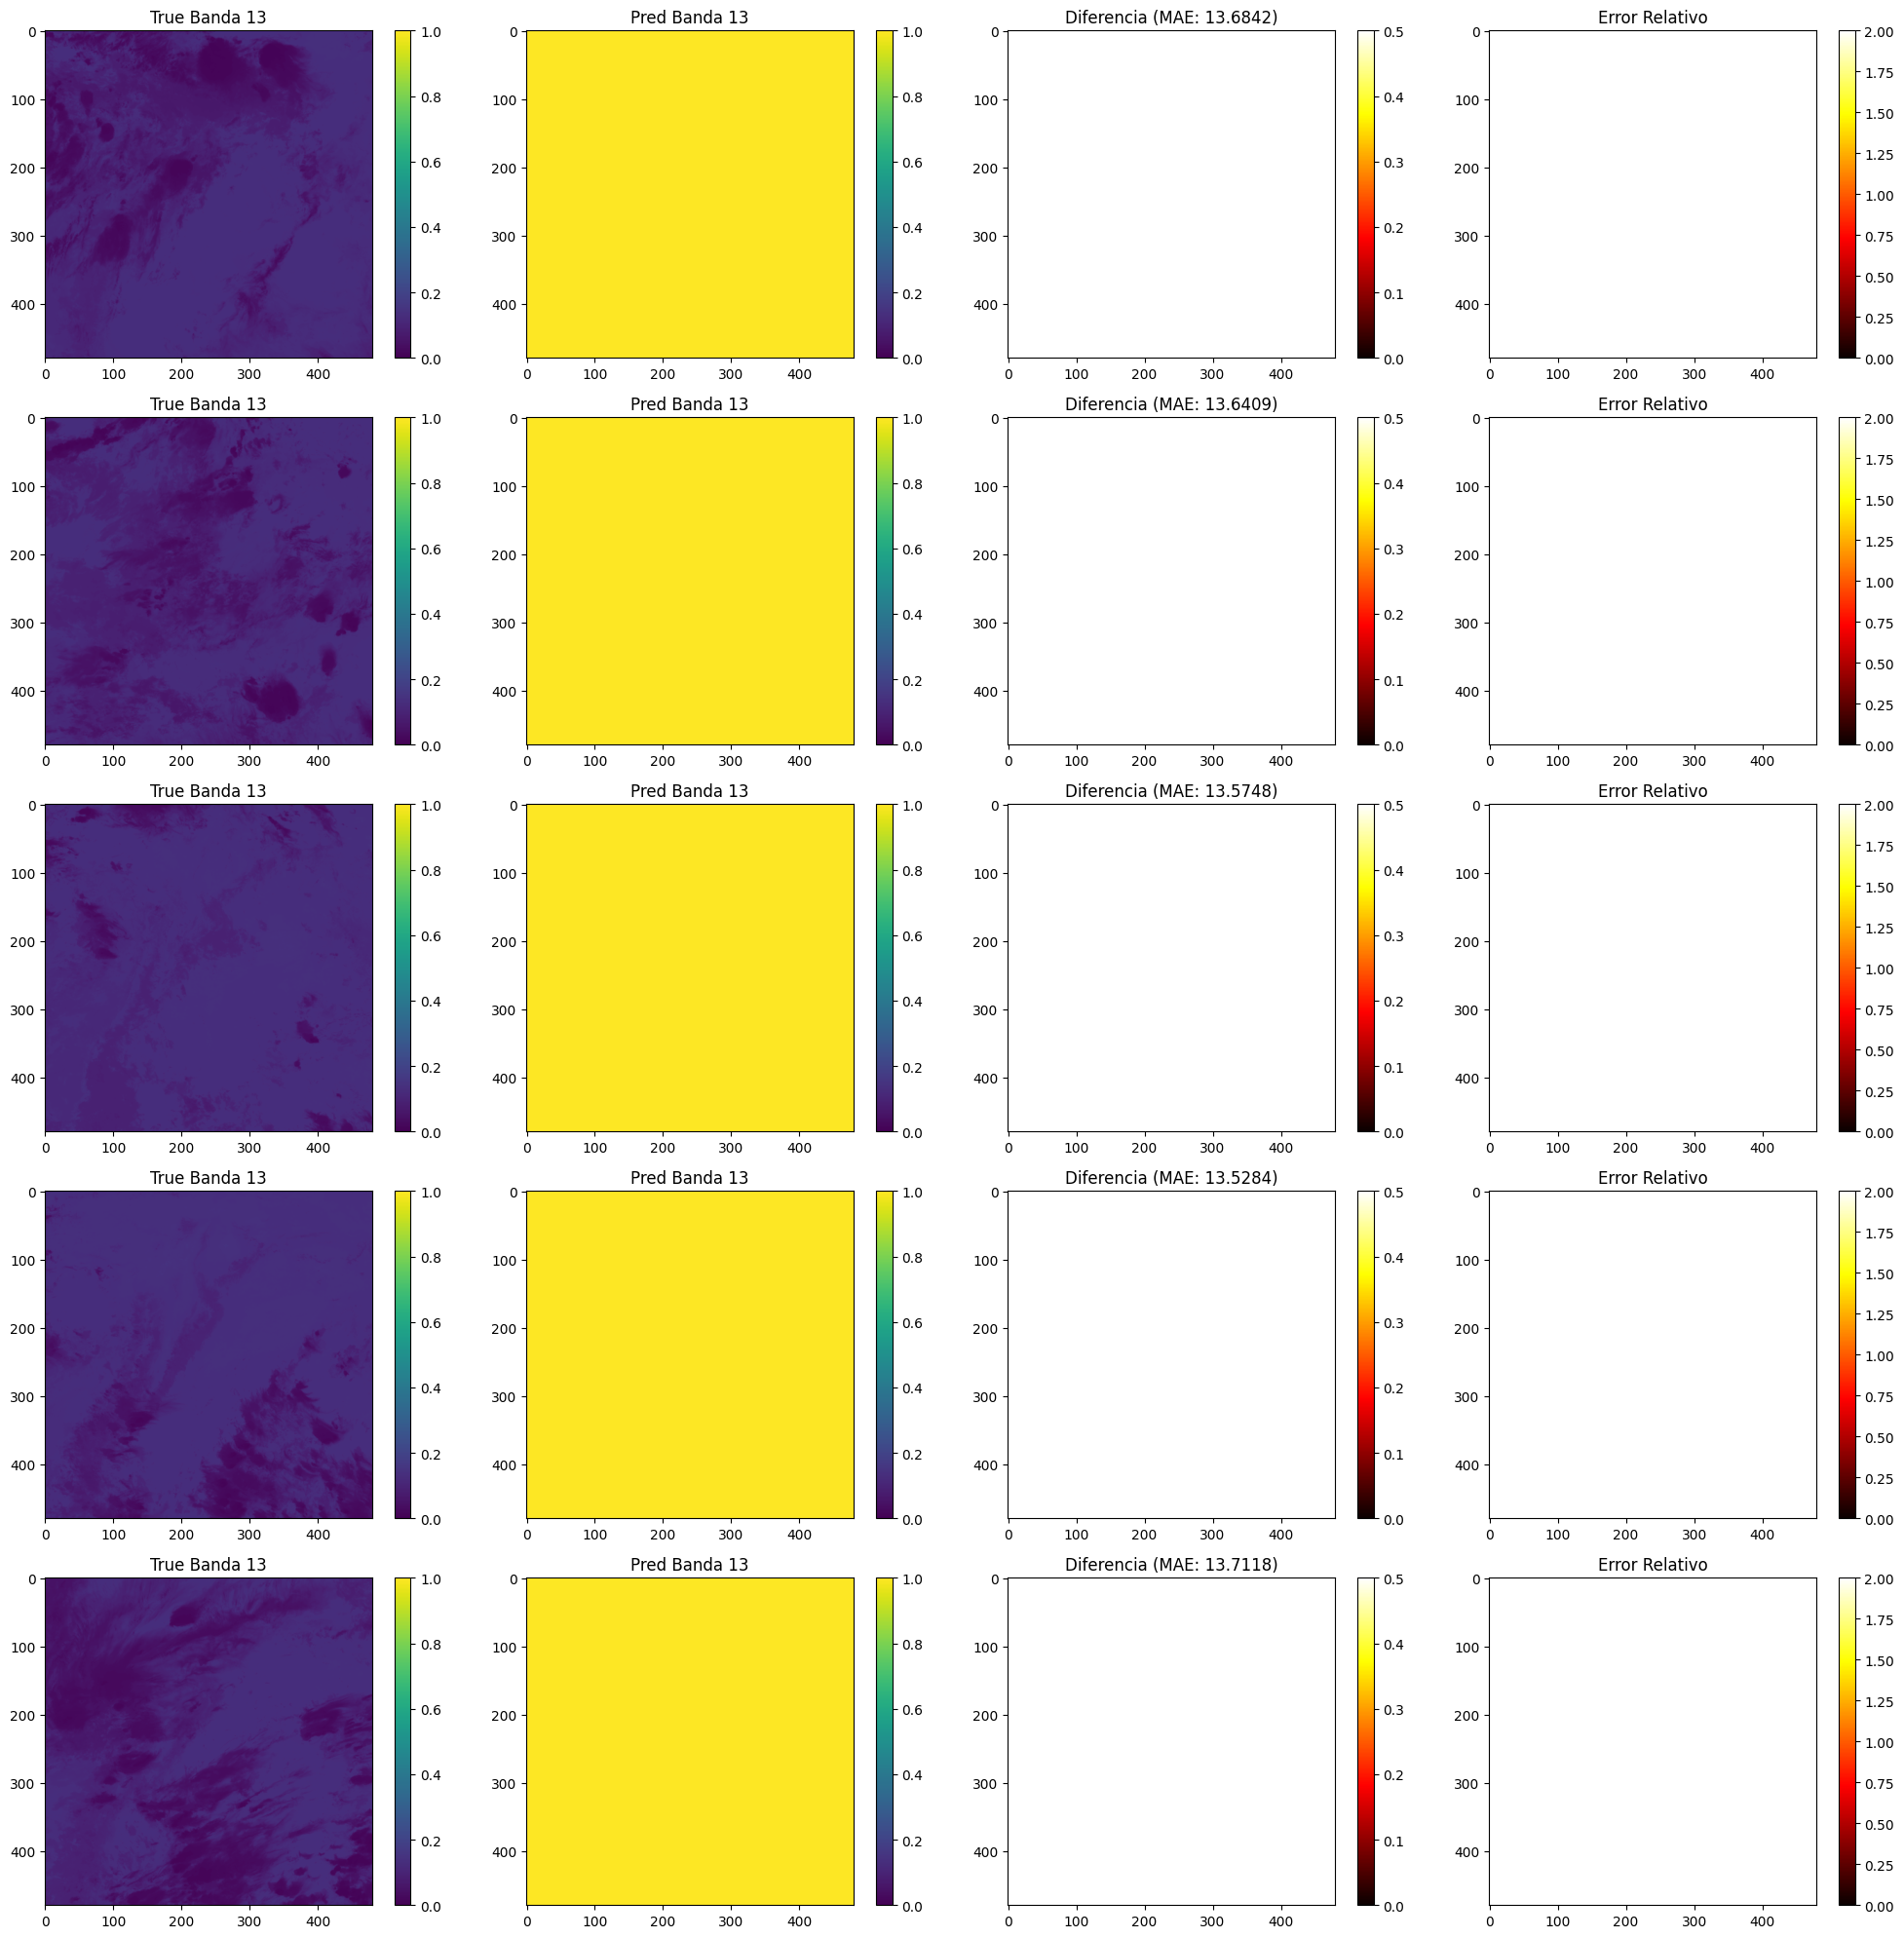

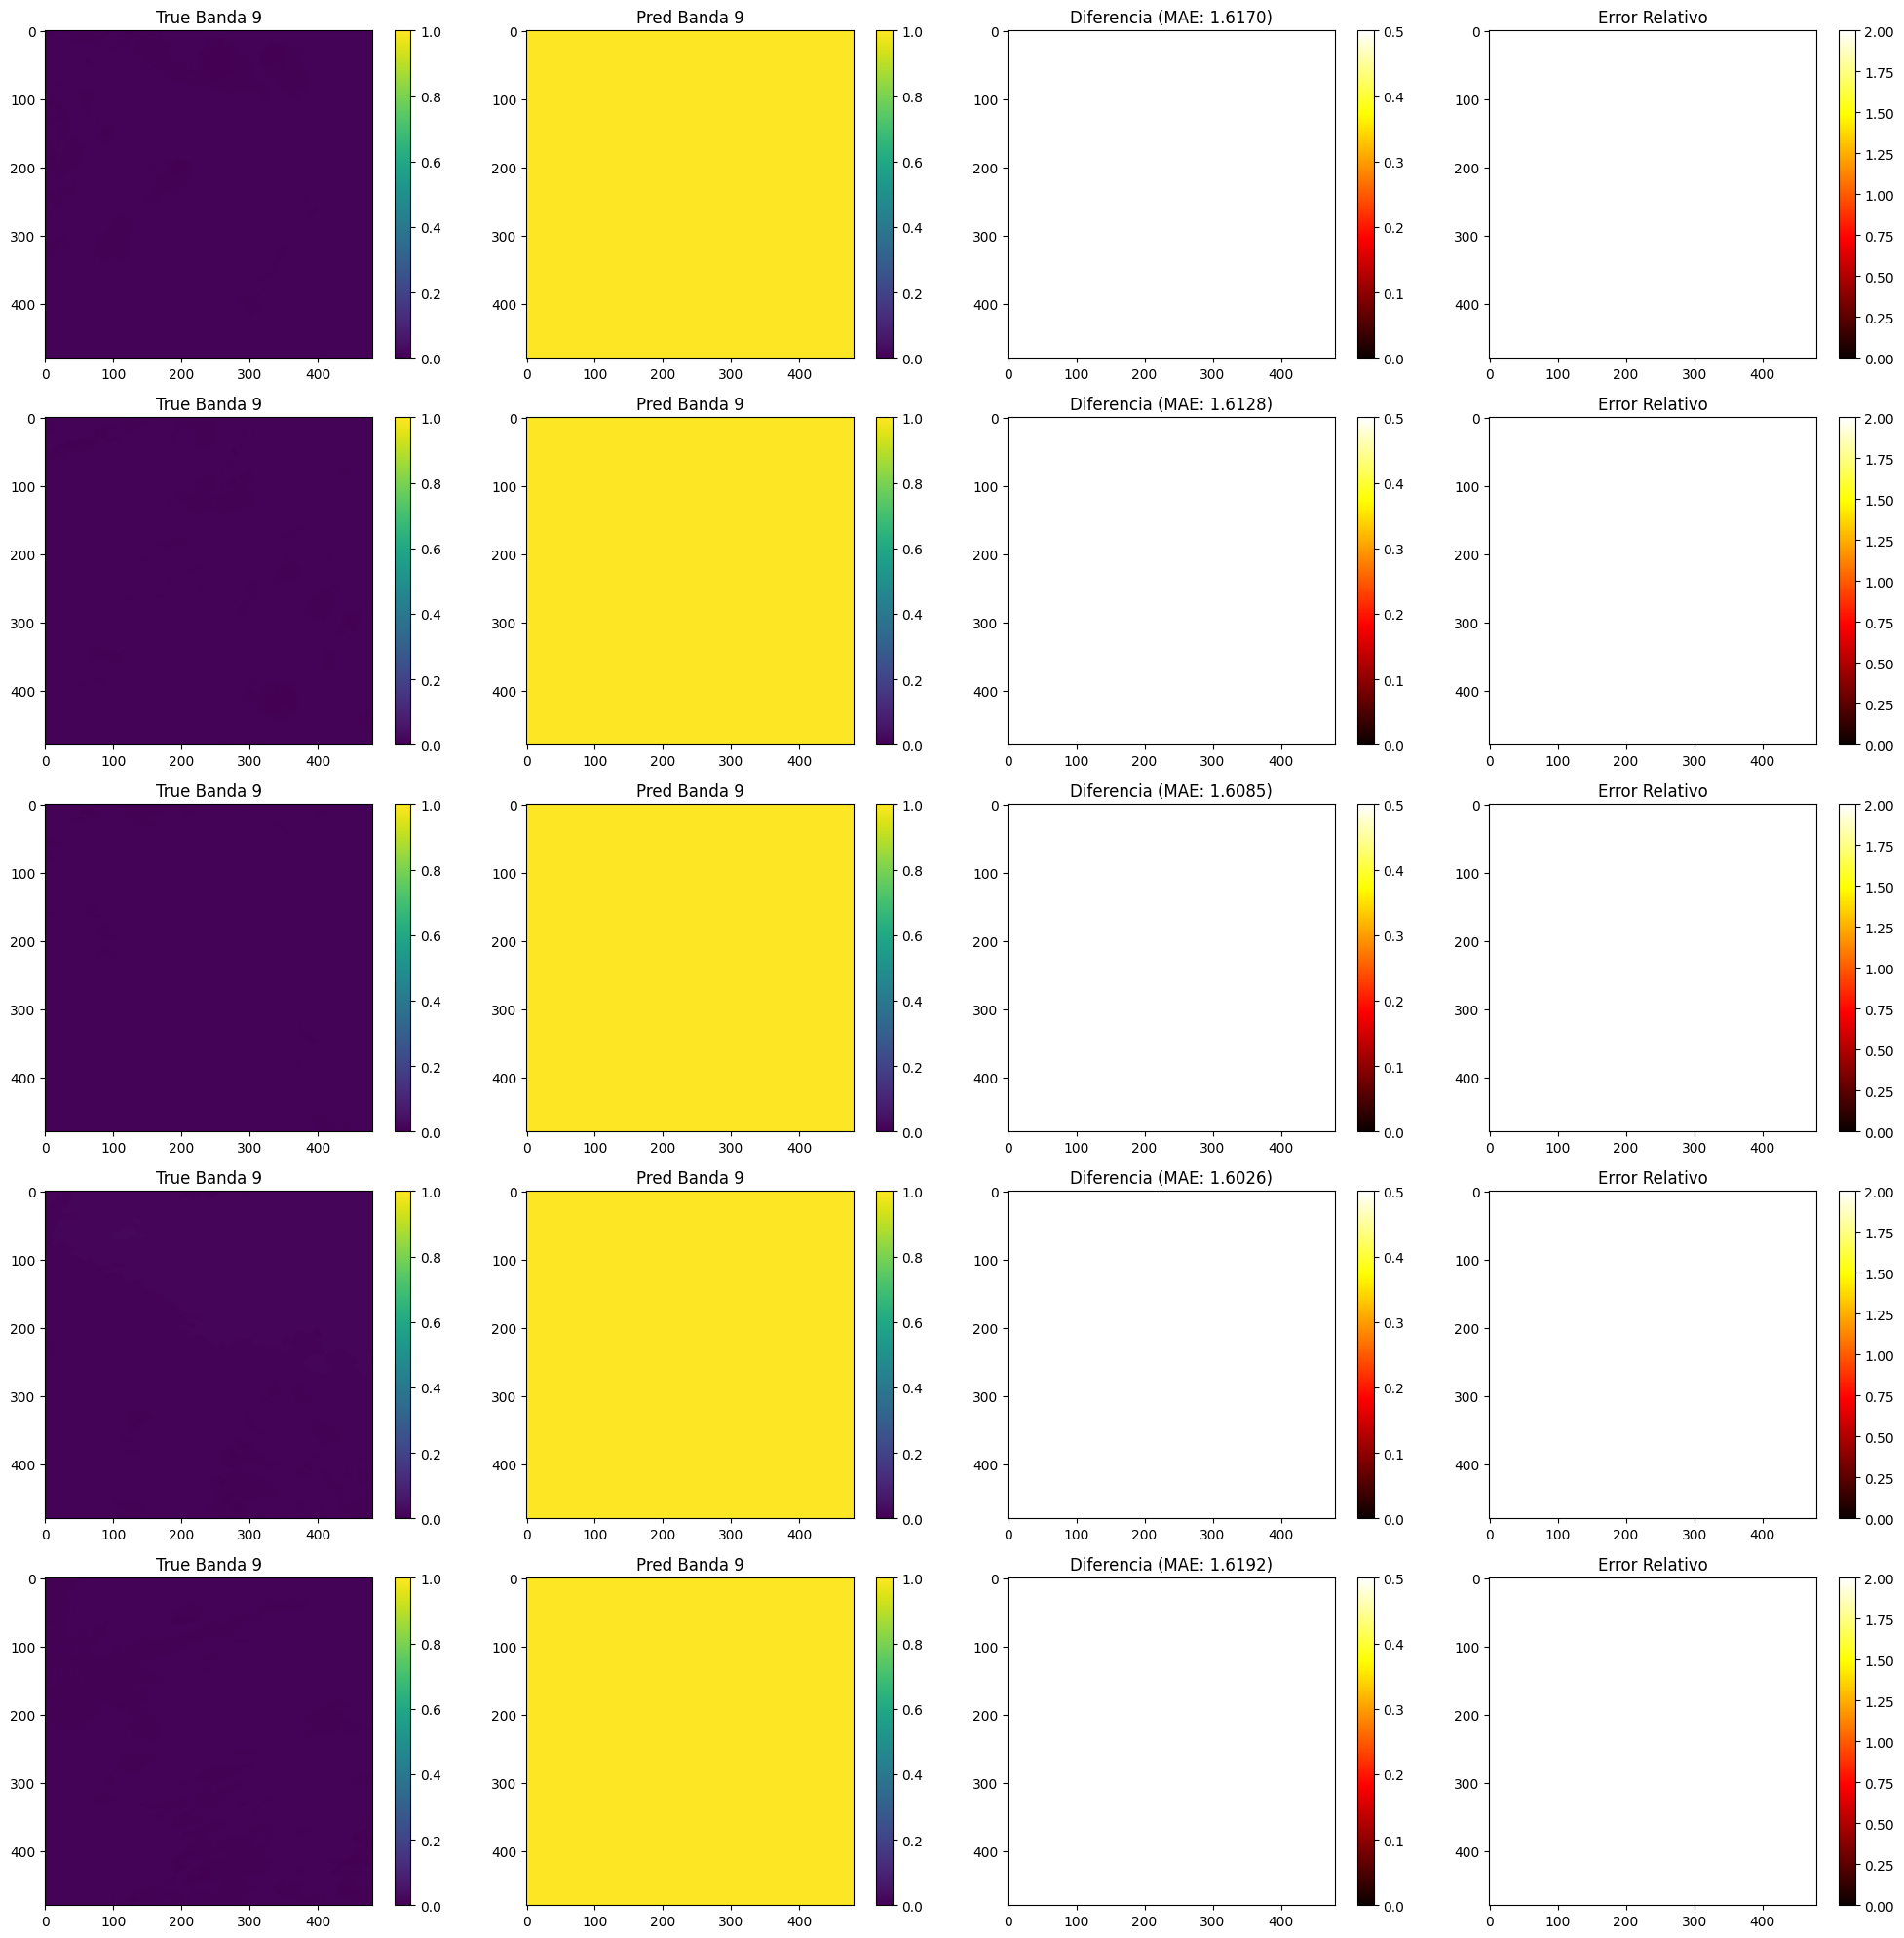


🎯 RESUMEN FINAL - MODELO MEJOR ÉPOCA
✅ BANDA 13:
   • MAE: 13.679078
   • MAPE: 18689.33%
   • Correlación: -0.0808
   • Precisos (5% std): 0.0%
✅ BANDA 9:
   • MAE: 1.616273
   • MAPE: 18057.49%
   • Correlación: -0.0436
   • Precisos (5% std): 0.0%

💾 Resultados guardados en 'resultados_mejor_epoca.npy'


In [22]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr
import os

# =====================================================
# CONFIGURACIÓN
# =====================================================
prueba_13_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'
prueba_9_red = '/home/jhon/bandas/banda9/nov_dic_2m_red'
model_path = 'modelo17_2b_best.h5'  # Tu modelo de mejor época
timesteps = 3

# =====================================================
# CARGA DEL MODELO (MEJOR ÉPOCA)
# =====================================================
print("🔧 Cargando modelo de la mejor época...")
model = tf.keras.models.load_model(model_path)
print(f"✅ Modelo '{model.name}' cargado exitosamente")

# Verificar arquitectura
print(f"Input shape esperado: {model.input_shape}")
print(f"Output shape esperado: {model.output_shape}")

# =====================================================
# FUNCIONES DE NORMALIZACIÓN MEJORADAS
# =====================================================
def smart_normalization(images, use_percentile=True):
    """
    Normalización inteligente que se adapta a la distribución de datos
    """
    all_pixels = np.concatenate([img.flatten() for img in images])
    
    if use_percentile:
        # Usar percentiles para ser robusto a outliers
        p1 = np.percentile(all_pixels, 1)
        p99 = np.percentile(all_pixels, 99)
        print(f"📊 Normalización por percentiles - P1: {p1:.4f}, P99: {p99:.4f}")
        return p1, p99
    else:
        # Usar media ± 3 std para distribución normal
        mean_val = np.mean(all_pixels)
        std_val = np.std(all_pixels)
        min_val = mean_val - 3 * std_val
        max_val = mean_val + 3 * std_val
        print(f"📊 Normalización por std - Min: {min_val:.4f}, Max: {max_val:.4f}")
        return min_val, max_val

def apply_normalization(images, min_val, max_val):
    """Aplicar normalización consistente"""
    normalized = []
    for img in images:
        img_norm = (img - min_val) / (max_val - min_val + 1e-8)
        img_norm = np.clip(img_norm, 0, 1)
        normalized.append(img_norm)
    return normalized

# =====================================================
# CARGA Y PREPARACIÓN DE DATOS
# =====================================================
print("\n📁 Cargando datos de prueba...")

# Cargar imágenes
images_test_13 = [np.load(os.path.join(prueba_13_red, f)) 
                 for f in sorted(os.listdir(prueba_13_red)) if f.endswith('.npy')]
images_test_9 = [np.load(os.path.join(prueba_9_red, f)) 
                for f in sorted(os.listdir(prueba_9_red)) if f.endswith('.npy')]

print(f"📊 Imágenes cargadas - Banda 13: {len(images_test_13)}, Banda 9: {len(images_test_9)}")

# Normalización CONSISTENTE para ambas bandas
print("\n🔄 Aplicando normalización consistente...")
min_val_13, max_val_13 = smart_normalization(images_test_13, use_percentile=True)
min_val_9, max_val_9 = smart_normalization(images_test_9, use_percentile=True)

# Usar los mismos parámetros para ambas bandas (importante!)
min_val = min(min_val_13, min_val_9)
max_val = max(max_val_13, max_val_9)
print(f"🎯 Parámetros finales - Min: {min_val:.4f}, Max: {max_val:.4f}")

images_test_13 = apply_normalization(images_test_13, min_val, max_val)
images_test_9 = apply_normalization(images_test_9, min_val, max_val)

# =====================================================
# PREPARACIÓN DE SECUENCIAS
# =====================================================
print("\n🔄 Preparando secuencias para predicción...")

# Convertir a arrays
X_base_test_13 = np.array(images_test_13)[..., np.newaxis]
X_base_test_9 = np.array(images_test_9)[..., np.newaxis]

# Asegurar mismo número de frames
n_frames = min(len(X_base_test_13), len(X_base_test_9))
X_base_test_13 = X_base_test_13[:n_frames]
X_base_test_9 = X_base_test_9[:n_frames]

# Crear secuencias combinadas
N_seq_test = n_frames - timesteps
X_seq_test = np.zeros((N_seq_test, timesteps, X_base_test_13.shape[1], 
                       X_base_test_13.shape[2], 2))
y_seq_test = np.zeros((N_seq_test, X_base_test_13.shape[1], 
                       X_base_test_13.shape[2], 2))

for i in range(N_seq_test):
    # Entrada: secuencia de 3 timesteps con 2 bandas
    seq_13 = X_base_test_13[i:i+timesteps]
    seq_9 = X_base_test_9[i:i+timesteps]
    X_seq_test[i] = np.concatenate([seq_13, seq_9], axis=-1)
    
    # Salida: siguiente frame con 2 bandas
    y_13 = X_base_test_13[i+timesteps]
    y_9 = X_base_test_9[i+timesteps]
    y_seq_test[i] = np.concatenate([y_13, y_9], axis=-1)

print(f"✅ Secuencias preparadas - X: {X_seq_test.shape}, y: {y_seq_test.shape}")

# =====================================================
# PREDICCIÓN CON EL MEJOR MODELO
# =====================================================
print("\n🎯 Realizando predicciones con el modelo de mejor época...")
y_pred = model.predict(X_seq_test, verbose=1)
print(f"✅ Predicciones completadas - Shape: {y_pred.shape}")

# =====================================================
# MÉTRICAS ROBUSTAS
# =====================================================
def safe_mape(y_true, y_pred, epsilon=1e-6):
    """MAPE seguro que evita división por cero"""
    mask = np.abs(y_true) > epsilon
    if np.sum(mask) == 0:
        return 100.0
    y_true_filtered = y_true[mask]
    y_pred_filtered = y_pred[mask]
    mape = np.mean(np.abs((y_true_filtered - y_pred_filtered) / y_true_filtered)) * 100
    return mape

def calculate_comprehensive_metrics(y_true, y_pred, band_name=""):
    """Métricas comprensivas y robustas"""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    # Métricas básicas
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    
    # Métricas robustas
    mape_safe = safe_mape(y_true_flat, y_pred_flat)
    corr, _ = pearsonr(y_true_flat, y_pred_flat)
    
    # Porcentaje dentro de tolerancias
    std_true = np.std(y_true_flat)
    within_10pct = np.mean(np.abs(y_true_flat - y_pred_flat) <= 0.1 * std_true) * 100
    within_05pct = np.mean(np.abs(y_true_flat - y_pred_flat) <= 0.05 * std_true) * 100
    
    print(f"\n--- {band_name} ---")
    print(f"MAE:      {mae:.6f}")
    print(f"RMSE:     {rmse:.6f}")
    print(f"MAPE:     {mape_safe:.2f}%")
    print(f"Corr:     {corr:.4f}")
    print(f"Within 5% std:  {within_05pct:.1f}%")
    print(f"Within 10% std: {within_10pct:.1f}%")
    
    return {
        'MAE': mae, 'RMSE': rmse, 'MAPE': mape_safe,
        'Correlation': corr, 'Within_5%': within_05pct, 'Within_10%': within_10pct
    }

# =====================================================
# EVALUACIÓN
# =====================================================
print("\n" + "="*50)
print("📊 EVALUACIÓN CON MODELO DE MEJOR ÉPOCA")
print("="*50)

# Evaluar por banda
metrics_13 = calculate_comprehensive_metrics(y_seq_test[..., 0], y_pred[..., 0], "BANDA 13")
metrics_9 = calculate_comprehensive_metrics(y_seq_test[..., 1], y_pred[..., 1], "BANDA 9")

# =====================================================
# VISUALIZACIÓN MEJORADA
# =====================================================
def plot_quality_assessment(y_true, y_pred, band_name, max_samples=5):
    """Visualización de calidad de predicciones"""
    samples_to_plot = min(max_samples, len(y_true))
    
    fig, axes = plt.subplots(samples_to_plot, 4, figsize=(20, 4*samples_to_plot))
    if samples_to_plot == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(samples_to_plot):
        idx = i * len(y_true) // samples_to_plot
        
        # True
        im0 = axes[i, 0].imshow(y_true[idx], cmap='viridis', vmin=0, vmax=1)
        axes[i, 0].set_title(f'True {band_name}')
        plt.colorbar(im0, ax=axes[i, 0])
        
        # Pred
        im1 = axes[i, 1].imshow(y_pred[idx], cmap='viridis', vmin=0, vmax=1)
        axes[i, 1].set_title(f'Pred {band_name}')
        plt.colorbar(im1, ax=axes[i, 1])
        
        # Diferencia absoluta
        diff = np.abs(y_true[idx] - y_pred[idx])
        im2 = axes[i, 2].imshow(diff, cmap='hot', vmin=0, vmax=0.5)
        axes[i, 2].set_title(f'Diferencia (MAE: {np.mean(diff):.4f})')
        plt.colorbar(im2, ax=axes[i, 2])
        
        # Error relativo
        with np.errstate(divide='ignore', invalid='ignore'):
            rel_error = np.abs(y_true[idx] - y_pred[idx]) / (y_true[idx] + 1e-8)
        rel_error = np.nan_to_num(rel_error, nan=0.0, posinf=0.0, neginf=0.0)
        im3 = axes[i, 3].imshow(rel_error, cmap='hot', vmin=0, vmax=2)
        axes[i, 3].set_title('Error Relativo')
        plt.colorbar(im3, ax=axes[i, 3])
    
    plt.tight_layout()
    plt.show()

print("\n🖼️ Generando visualizaciones...")
plot_quality_assessment(y_seq_test[..., 0], y_pred[..., 0], "Banda 13")
plot_quality_assessment(y_seq_test[..., 1], y_pred[..., 1], "Banda 9")

# =====================================================
# RESUMEN FINAL
# =====================================================
print("\n" + "="*50)
print("🎯 RESUMEN FINAL - MODELO MEJOR ÉPOCA")
print("="*50)

print(f"✅ BANDA 13:")
print(f"   • MAE: {metrics_13['MAE']:.6f}")
print(f"   • MAPE: {metrics_13['MAPE']:.2f}%")
print(f"   • Correlación: {metrics_13['Correlation']:.4f}")
print(f"   • Precisos (5% std): {metrics_13['Within_5%']:.1f}%")

print(f"✅ BANDA 9:")
print(f"   • MAE: {metrics_9['MAE']:.6f}")
print(f"   • MAPE: {metrics_9['MAPE']:.2f}%")
print(f"   • Correlación: {metrics_9['Correlation']:.4f}")
print(f"   • Precisos (5% std): {metrics_9['Within_5%']:.1f}%")

# Guardar resultados
results = {
    'banda_13': metrics_13,
    'banda_9': metrics_9,
    'normalization_params': {'min': min_val, 'max': max_val},
    'model_info': {'name': model.name, 'input_shape': model.input_shape}
}

np.save('resultados_mejor_epoca.npy', results)
print(f"\n💾 Resultados guardados en 'resultados_mejor_epoca.npy'")

Prueba

In [17]:
# Directorio original y reducido para validación
prueba_13_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Cargar imágenes
file_list_test = sorted([f for f in os.listdir(prueba_13_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test_13 = [np.load(os.path.join(prueba_13_red, f)) for f in file_list_test]

#Cargar el modelo entrenado
model = tf.keras.models.load_model('modelo17_2b_best.h5')

# Estrategia: Usar estadísticas robustas de los datos de prueba
def robust_normalization(images):
    """Normalización robusta usando percentiles"""
    all_pixels = np.concatenate([img.flatten() for img in images])
    
    # Usar percentiles para evitar outliers
    p05 = np.percentile(all_pixels, 0.5)   # Similar al mínimo sin outliers
    p995 = np.percentile(all_pixels, 99.5) # Similar al máximo sin outliers
    
    print(f"Normalización robusta - P0.5: {p05:.4f}, P99.5: {p995:.4f}")
    return p05, p995

# Aplicar normalización robusta
train_min_est, train_max_est = robust_normalization(images_test_13)

images_test_13 = [(img - train_min_est) / (train_max_est - train_min_est + 1e-8) for img in images_test_13]
images_test_13 = [np.clip(img, 0, 1) for img in images_test_13]

print(f"Rango después de normalizar: [{np.min(images_test_13):.4f}, {np.max(images_test_13):.4f}]")

Procesando 1447 imágenes para validación


Normalización robusta - P0.5: 0.0006, P99.5: 0.0006
Rango después de normalizar: [0.0000, 0.1861]


In [18]:
prueba_9_red = '/home/jhon/bandas/banda9/nov_dic_2m_red'

# Cargar imágenes
file_list_test = sorted([f for f in os.listdir(prueba_9_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test_9 = [np.load(os.path.join(prueba_9_red, f)) for f in file_list_test]

#Cargar el modelo entrenado
model = tf.keras.models.load_model('modelo17_2b_best.h5')

# Estrategia: Usar estadísticas robustas de los datos de prueba
def robust_normalization(images):
    """Normalización robusta usando percentiles"""
    all_pixels = np.concatenate([img.flatten() for img in images])
    
    # Usar percentiles para evitar outliers
    p05 = np.percentile(all_pixels, 0.5)   # Similar al mínimo sin outliers
    p995 = np.percentile(all_pixels, 99.5) # Similar al máximo sin outliers
    
    print(f"Normalización robusta - P0.5: {p05:.4f}, P99.5: {p995:.4f}")
    return p05, p995

# Aplicar normalización robusta
train_min_est, train_max_est = robust_normalization(images_test_13)

images_test_9 = [(img - train_min_est) / (train_max_est - train_min_est + 1e-8) for img in images_test_9]
images_test_9 = [np.clip(img, 0, 1) for img in images_test_9]

print(f"Rango después de normalizar: [{np.min(images_test_9):.4f}, {np.max(images_test_9):.4f}]")

Procesando 1447 imágenes para validación


Normalización robusta - P0.5: 0.0000, P99.5: 0.1358
Rango después de normalizar: [0.0047, 0.0047]


In [11]:
# Combinar ambos conjuntos de datos
X_multi_test = np.concatenate([X_seq_test_13, X_seq_test_9], axis=-1)
y_multi_test= np.concatenate([y_seq_test_13, y_seq_test_9], axis=-1)

print("Forma de X multi test", X_multi_test.shape)
print("Forma de y multi test:", y_multi_test.shape)

Forma de X multi test (1444, 3, 480, 480, 2)
Forma de y multi test: (1444, 480, 480, 2)


In [12]:
# Ahora puedes evaluar el modelo
loss, rmse, mape = model17_2b.evaluate(X_multi_test, y_multi_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - loss: 7.2436 - mean_absolute_percentage_error: 816758272.0000 - root_mean_squared_error: 9.8856
Pérdida (MSE): 7.2436
RMSE: 9.8856
MAPE: 816758272.0000


46/46 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step


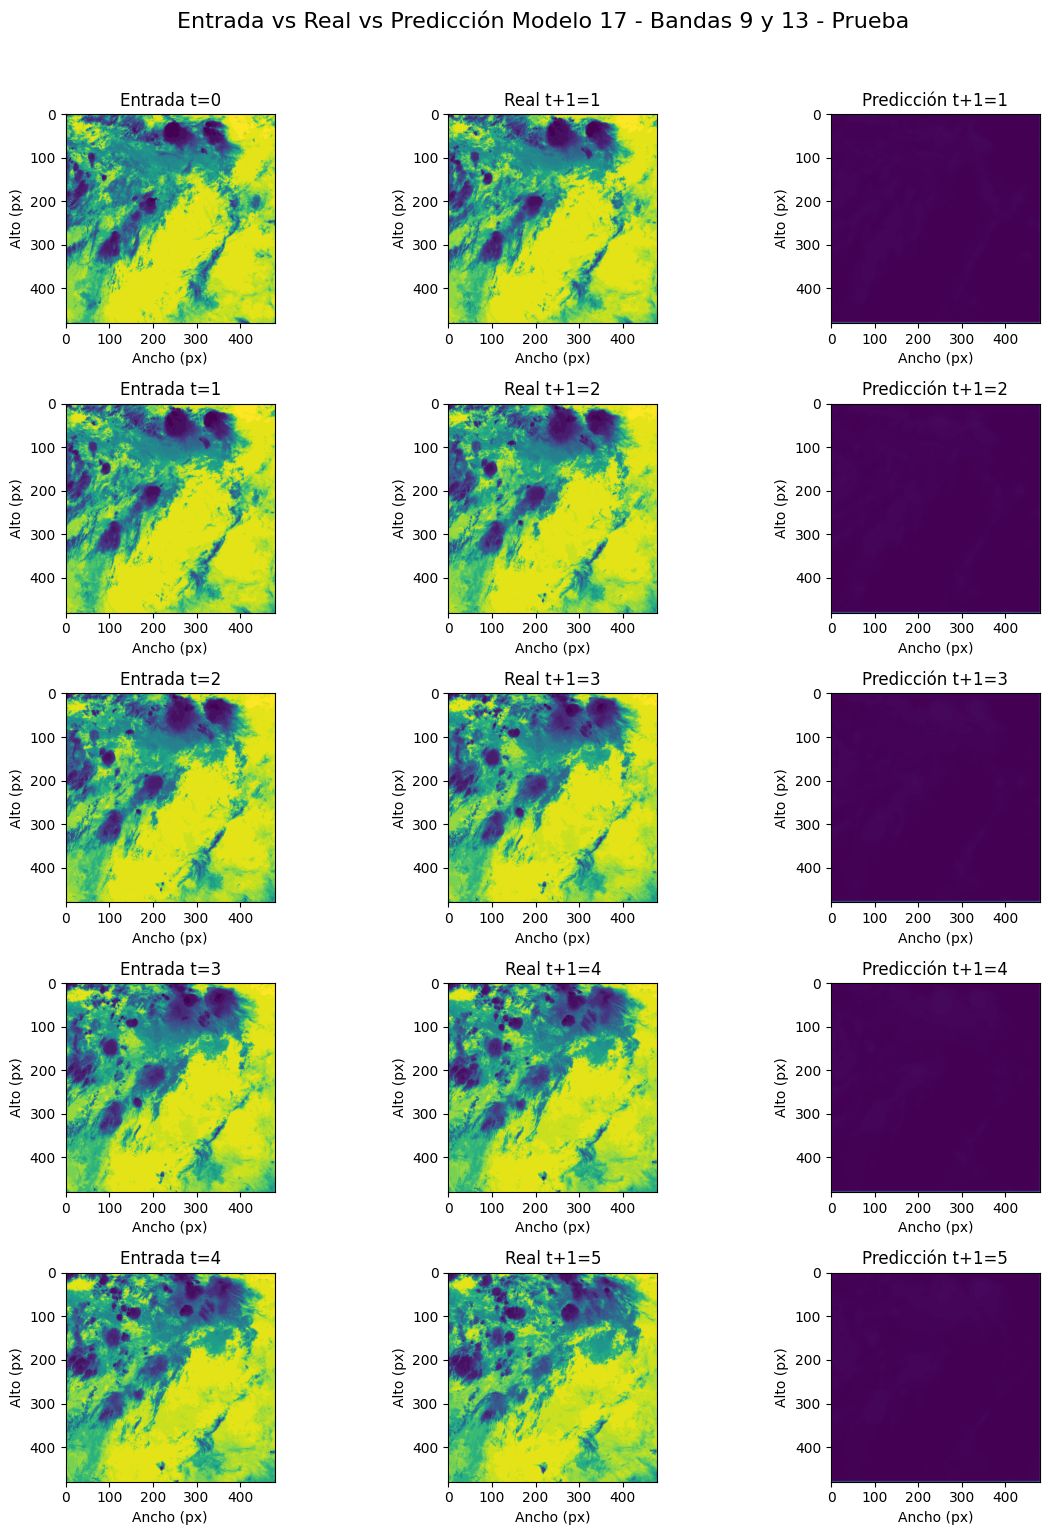

In [15]:
y_pred17_test_2b = model17_2b.predict(X_multi_test)  # Genera las predicciones usando X_seq_val
mostrar_resultados(
    X_multi_test[:, -1, :, :, :],  # Toma solo el último timestep de la secuencia de entrada
    y_multi_test,                   # Valores reales
    y_pred17_test_2b,                # Predicciones
    n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 17 - Bandas 9 y 13 - Prueba",
    xlabel="Ancho (px)",
    ylabel="Alto (px)"
)